Leitura dos dados no disco

In [6]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube

/home/fabiene/anaconda3/envs/orange3/bin/python


In [2]:
import sys
print(sys.version)


3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


In [3]:
!conda list


# packages in environment at /home/fabiene/anaconda3/envs/orange3:
#
# Name                    Version                   Build  Channel
_libgcc_mutex             0.1                        main  
_openmp_mutex             5.1                       1_gnu  
_py-xgboost-mutex         2.0                       cpu_0    conda-forge
accelerate                1.12.0                   pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.13.2                   pypi_0    pypi
aiosignal                 1.4.0                    pypi_0    pypi
anyio                     4.11.0             pyhcf101f3_0    conda-forge
anyqt                     0.2.1              pyhd8ed1ab_0    conda-forge
aom                       3.9.1                hac33072_0    conda-forge
argon2-cffi               21.3.0             pyhd3eb1b0_0  
argon2-cffi-bindings      25.1.0          py310hee96239_0  
asttokens                 3.0.0              pyhd8ed1ab_1    conda-f

In [4]:
import subprocess

# Executa o comando e captura o texto resultante
resultado = subprocess.check_output(["conda", "list"]).decode("utf-8")
print(resultado)

# packages in environment at /home/fabiene/anaconda3/envs/orange3:
#
# Name                    Version                   Build  Channel
_libgcc_mutex             0.1                        main  
_openmp_mutex             5.1                       1_gnu  
_py-xgboost-mutex         2.0                       cpu_0    conda-forge
accelerate                1.12.0                   pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.13.2                   pypi_0    pypi
aiosignal                 1.4.0                    pypi_0    pypi
anyio                     4.11.0             pyhcf101f3_0    conda-forge
anyqt                     0.2.1              pyhd8ed1ab_0    conda-forge
aom                       3.9.1                hac33072_0    conda-forge
argon2-cffi               21.3.0             pyhd3eb1b0_0  
argon2-cffi-bindings      25.1.0          py310hee96239_0  
asttokens                 3.0.0              pyhd8ed1ab_1    conda-f

In [5]:
import torch
import torchvision
import matplotlib
import PIL

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision (Processa as imagens): {torchvision.__version__}")
print(f"Matplotlib (Gera os gráficos): {matplotlib.__version__}")
print(f"Pillow (Lê os pixels): {PIL.__version__}")

PyTorch: 2.9.1+cpu
Torchvision (Processa as imagens): 0.24.1+cpu
Matplotlib (Gera os gráficos): 3.10.6
Pillow (Lê os pixels): 11.3.0


# Projeto 14: Rede Neural Convolucional Gatos e Cachorros

## Etapa 1: Importação das bibliotecas

In [7]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import zipfile
torch.__version__

'2.9.1+cpu'

In [8]:
torch.manual_seed(123) # para sempre termos o mesmo resultado

## Etapa 2: Construção do modelo

kernel = 3

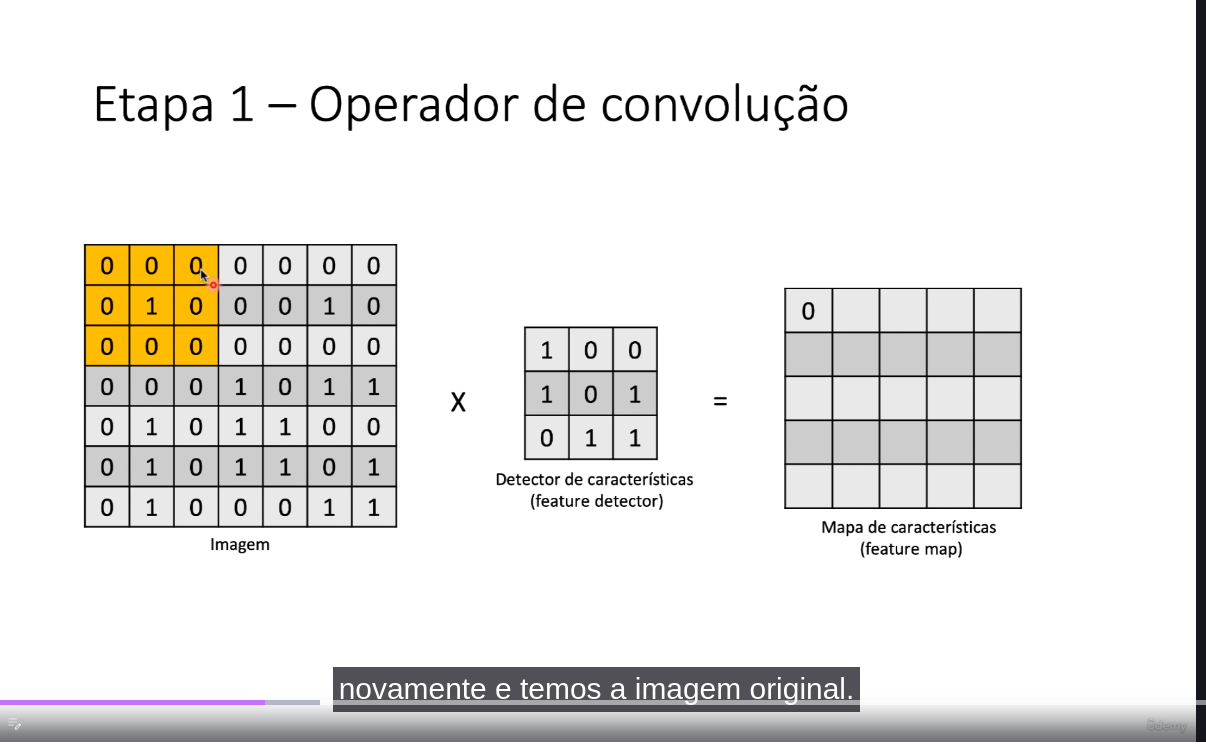

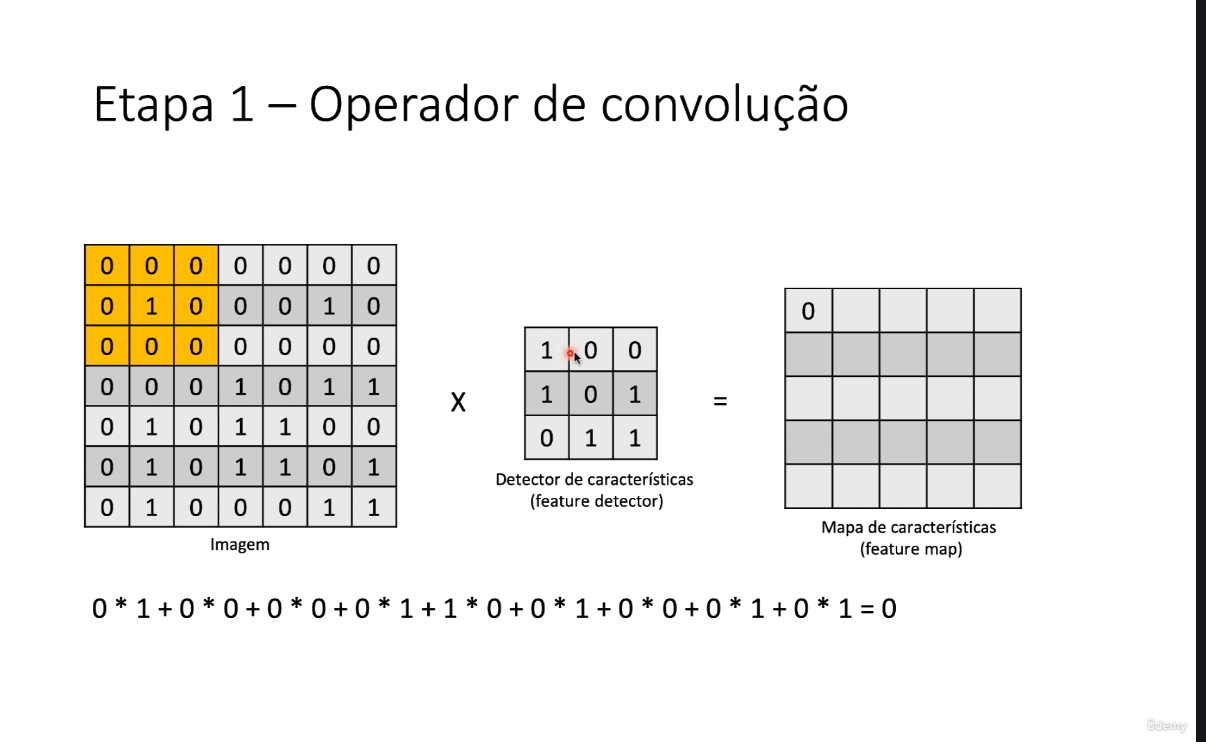

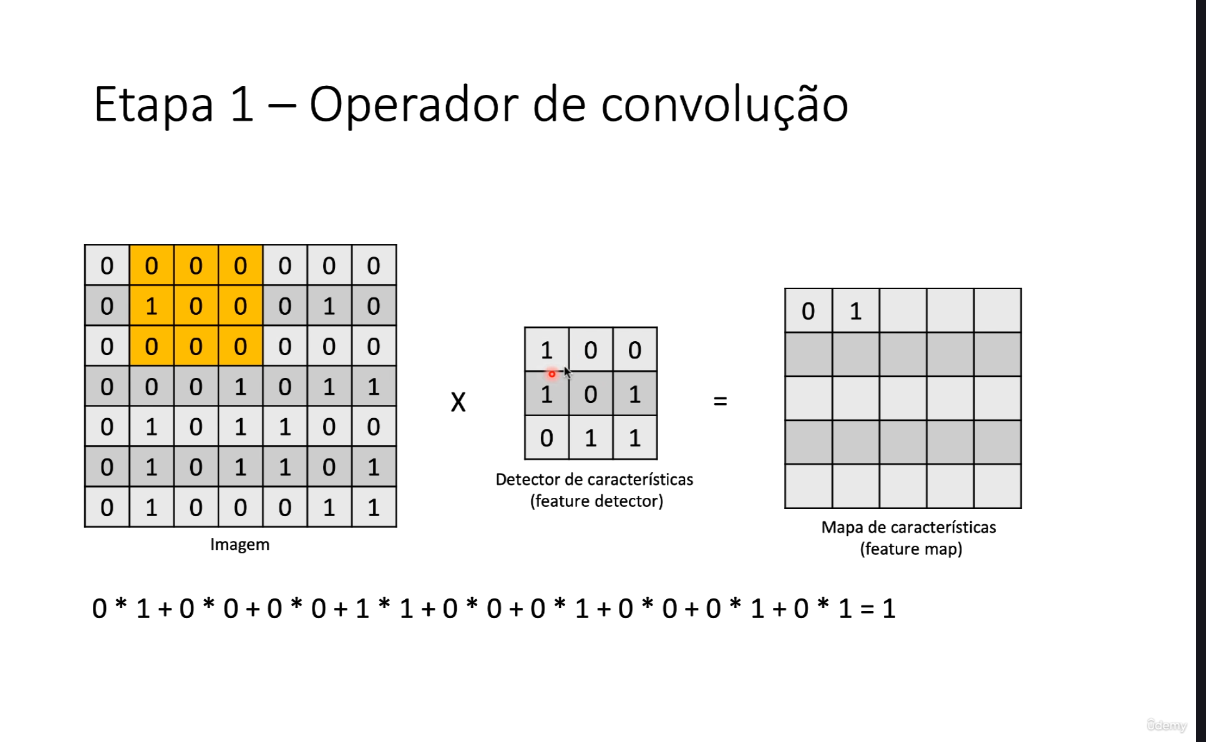

deslocando pixel a pixel
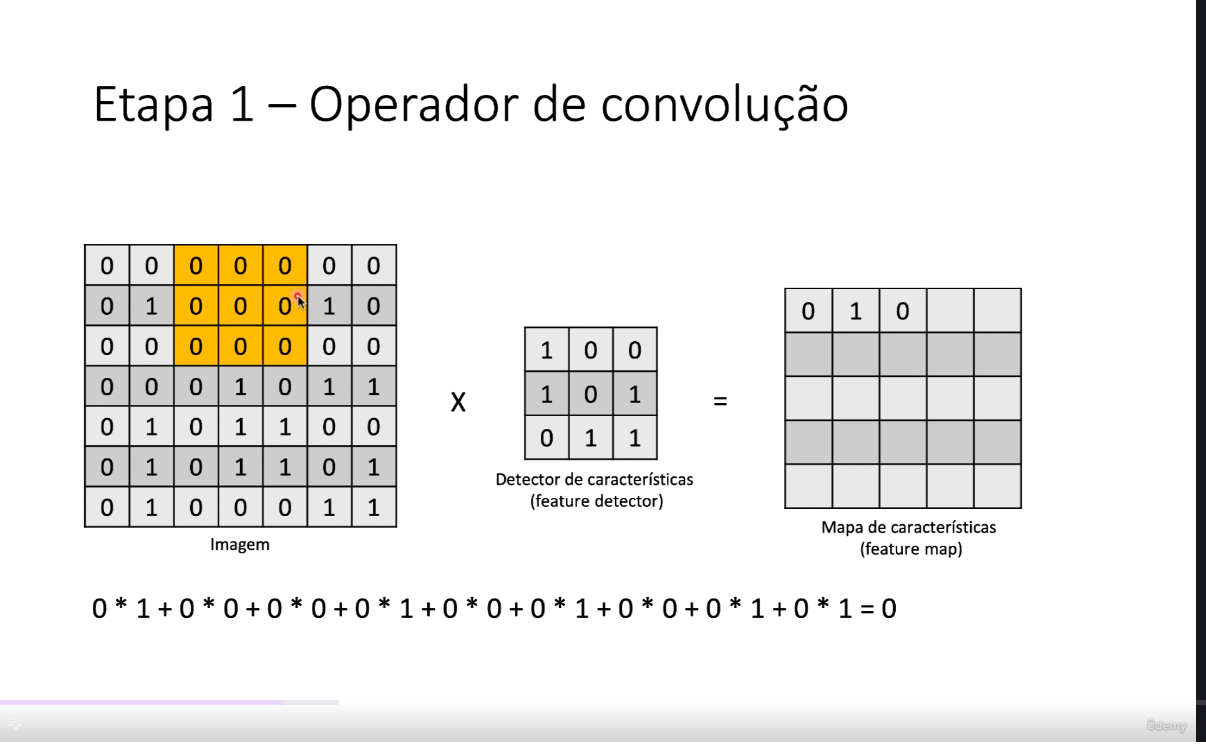

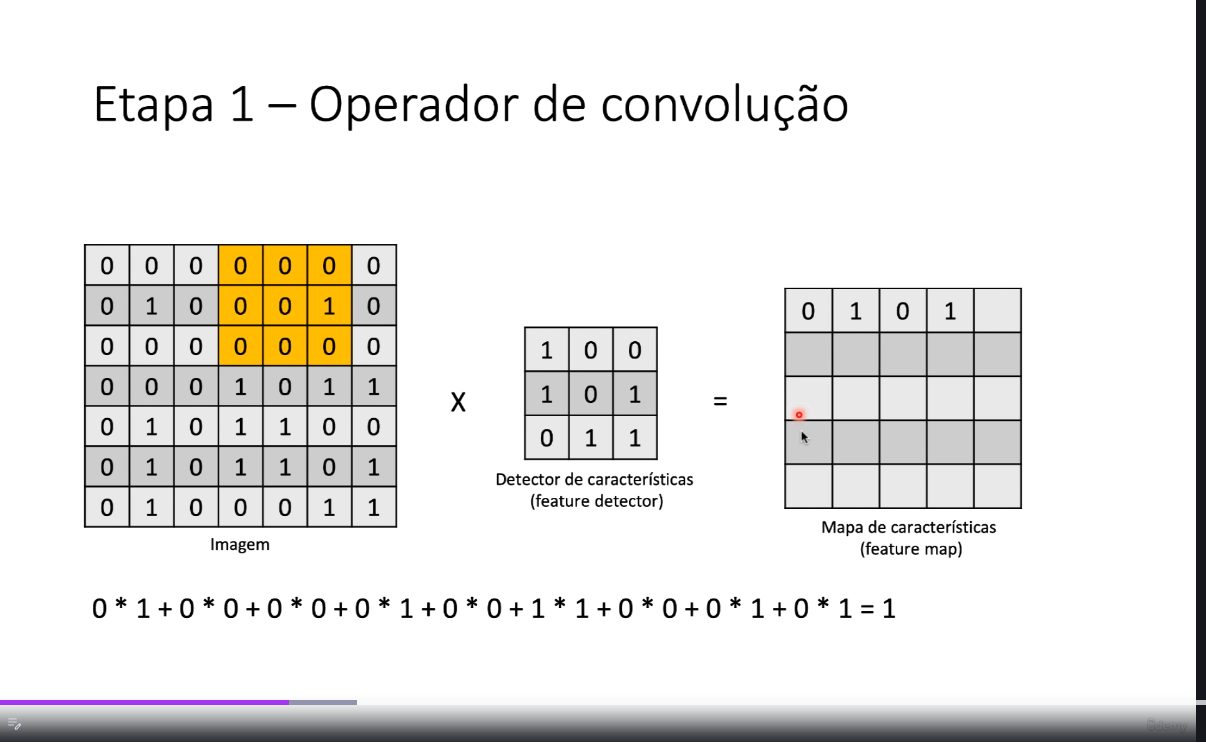

## Comando ReLU()

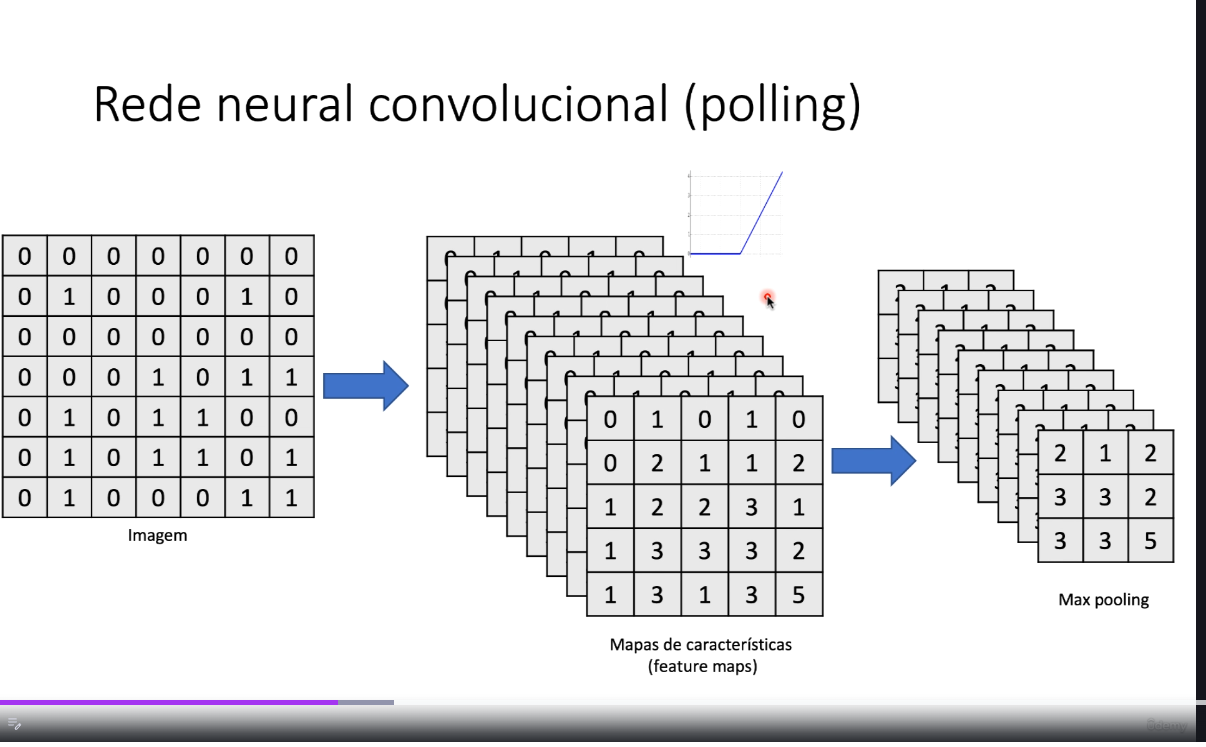

## MaxPool2d, escolha dos maiores valores


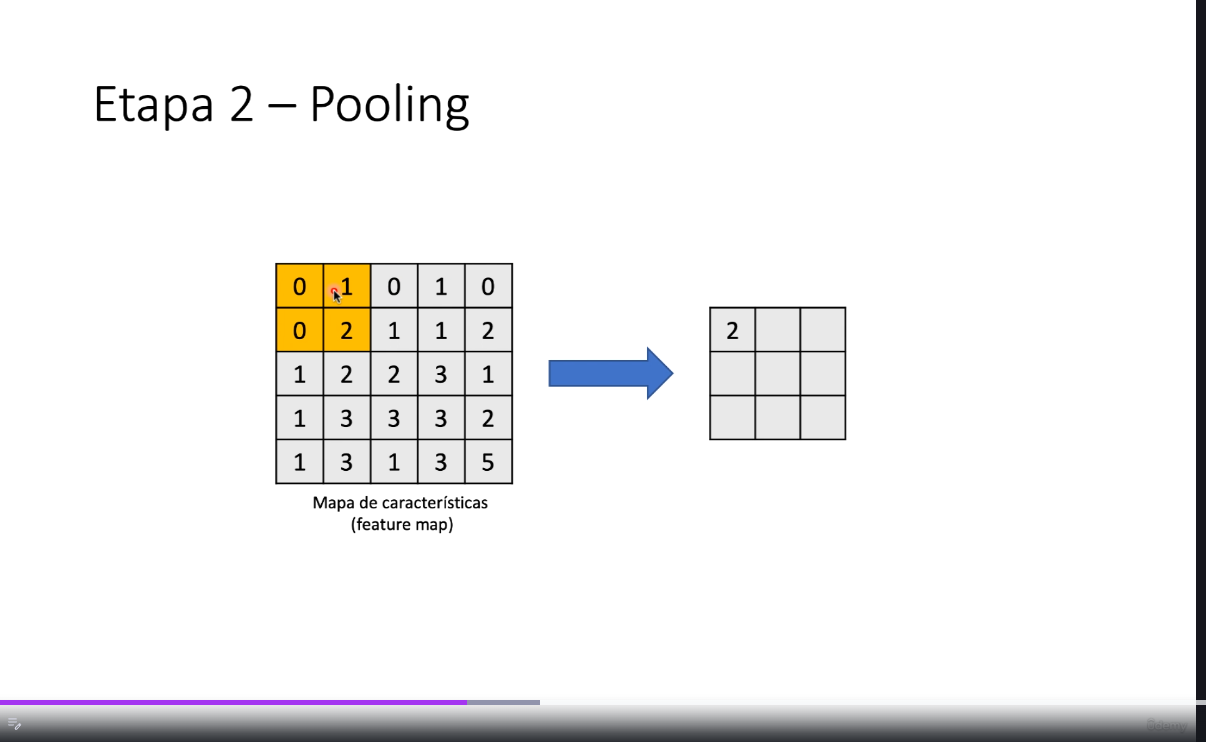


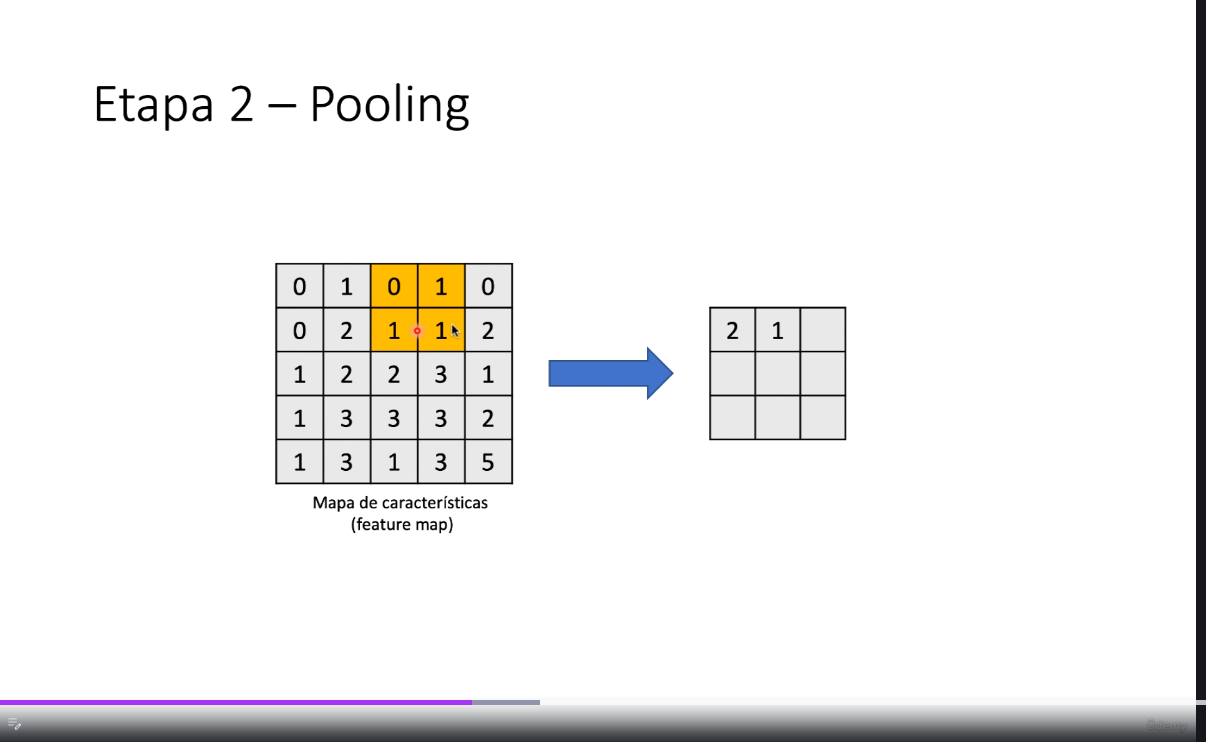


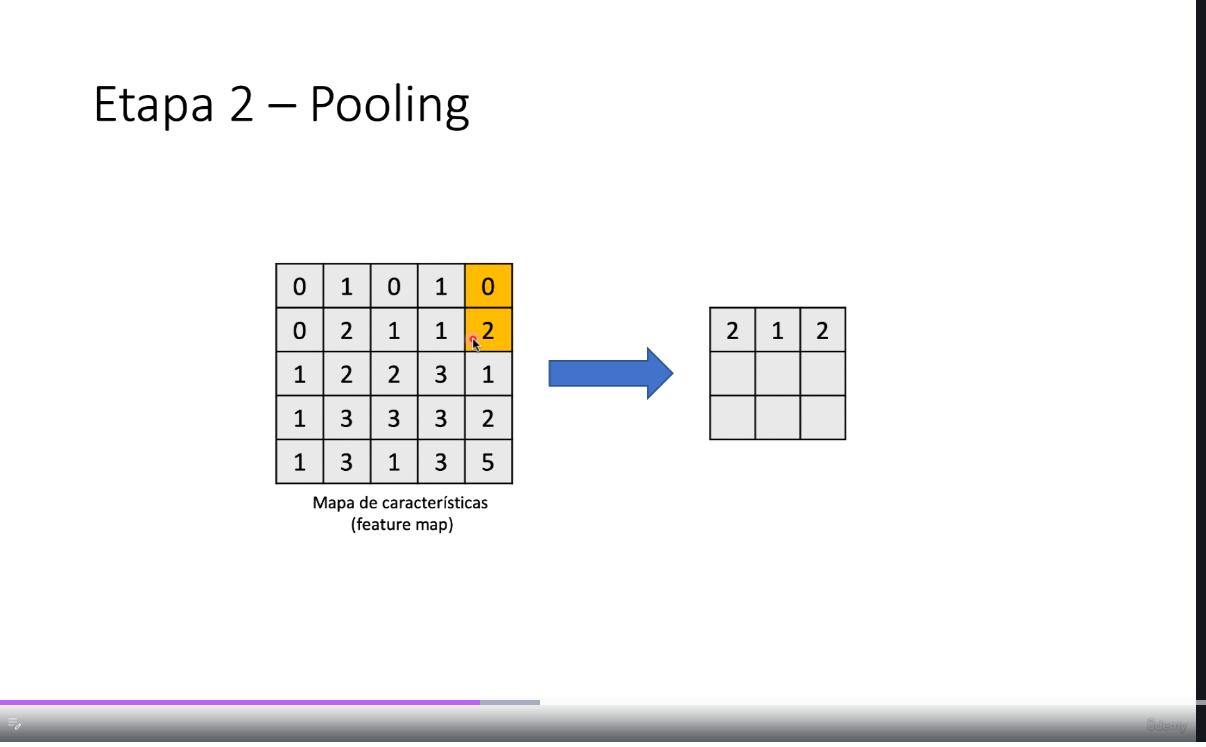

In [27]:
# Definindo a arquitetura como uma sequência linear de camadas
# output = (input - filter + 1) / stride
classificador = nn.Sequential(
                             # 1. CONVOLUÇÃO: Entrada 3 canais (RGB), Saída 32 mapas. Kernel 3x3 reduz 2 pixels (64-3+1 = 62)
                              #camada convolucional com canal de cores, por isso 3 RGB, vermelho, verde e azul
                              # 32 filtros no out_channels, matriz 3x 3 no kernel_size
                              nn.Conv2d(in_channels=3, out_channels=32, kernel_size = 3),
                              nn.ReLU(), # Ativação: Mantém positivos, zera negativos
                              # BatchNorm2d: Normalização: Estabiliza os dados para o treino ser mais rápido
                              # normalização nas camadas ocultas, no num_features igual ao número dos filtroa
                              nn.BatchNorm2d(num_features=32),
                              # (64 - 3 + 1) / 1 = 62x62

                              # 2. POOLING: Reduz a dimensão espacial pela metade (62 / 2 = 31)
                              nn.MaxPool2d(kernel_size = 2), # Resultado: 32 mapas de 31x31

                              # 3. CONVOLUÇÃO: Recebe 32, solta 32. Kernel 3x3 reduz mais 2 pixels (31-3+1 = 29)
                              # 31x31
                              nn.Conv2d(32, 32, 3),
                              nn.ReLU(),
                              nn.BatchNorm2d(32),
                              # (31 - 3 + 1) / 1 = 29x29

                              # 4. POOLING: Reduz novamente (29 / 2 = 14.5 -> Arredonda para 14)
                              nn.MaxPool2d(2), # tamanho o filtro também será 2x2
                              # MaxPool2d(2) => Resultado: 32 mapas de 14x14
                              #  14x14
                              # 5. FLATTEN: Transforma a matriz 3D (32, 14, 14) em um vetor 1D de 6272 elementos
                              nn.Flatten(), # última parte, converter a matriz para 1 vetor
                              # 6272 -> 128 -> 128 -> 1
                    
                              # 6. LINEAR 1: Recebe o vetor de 6272 e conecta a 128 neurônios
                              # converter para rede neural densa
                              nn.Linear(in_features=14*14*32, out_features=128),
                              nn.ReLU(),
                              # "Apaga" 20% da camada para evitar que a rede fique 'viciada' em detalhes inúteis.
                              # Overfitting (quando a rede apenas "decora" o banco de dados de treino mas falha feio na vida real).
                              nn.Dropout(0.2), # 20% dos neurônios serão zerados

                              # 7. LINEAR 2: Camada oculta extra com 128 neurônios
                              nn.Linear(128, 128),
                              nn.ReLU(),
                              nn.Dropout(0.2),
    
                              # 8. SAÍDA: Reduz para 1 neurônio final (Classificação Binária)
                              nn.Linear(128, 1), # saída um, pois só queremos classificar gatos ou cachorros.

                              # 9. SIGMOID: Transforma o resultado em uma probabilidade entre 0 e 1 (ex: 0.8 = 80% de chance)
                              nn.Sigmoid() # função sigmoid
                             # Converte a saída final em um valor entre 0 e 1 (ideal para sim/não)

                           )

fatten()

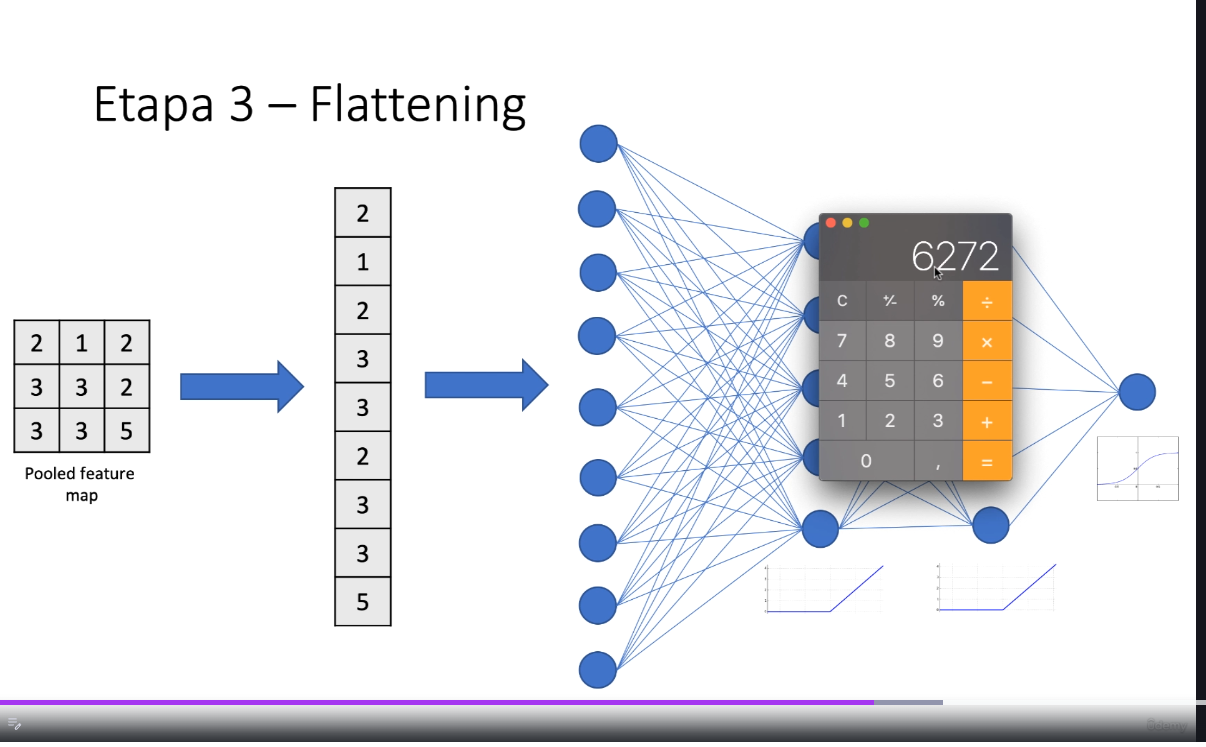

A função Sigmoid é uma das funções de ativação mais clássicas do Deep Learning. Ela atua como um "esmagador" de números, pegando qualquer valor (seja $-1000$ ou $+1000$) e forçando-o a ficar dentro de um intervalo fixo entre 0 e 1.

na rede neural:

A fórmula da Sigmoid é:$$f(x) = \frac{1}{1 + e^{-x}}$$Se o neurônio gera um número muito alto, a Sigmoid entrega algo próximo de 1.Se o neurônio gera um número muito baixo (negativo), ela entrega algo próximo de 0.Se o valor for 0, ela entrega exatamente 0.5.

Transformar em Probabilidade: Como o resultado está entre 0 e 1, você pode interpretar a saída como uma porcentagem.Exemplo: 0.85 significa "85% de chance de ser a classe positiva".Classificação Binária: Ela é o padrão ouro para problemas de "Sim ou Não".Se a saída for $> 0.5$, você classifica como Classe A.Se for $< 0.5$, como Classe B.

# feito a construção do modelo 

In [29]:
criterion = nn.BCELoss() # A régua que mede o erro para problemas de Sim/Não.
optimizer = optim.Adam(classificador.parameters()) # O mecanismo que ajusta os pesos para diminuir o erro.

1. criterion = nn.BCELoss()
O Medidor de Erro Binário

O que significa: Binary Cross Entropy Loss (Perda de Entropia Cruzada Binária).

O que faz: Ela calcula a diferença entre a probabilidade que a rede previu (ex: 0.8) e o rótulo real (0 ou 1).

Por que usar aqui: É a função obrigatória quando sua saída é um único neurônio com Sigmoid. Ela é muito eficiente em "empurrar" os valores para perto de 0 ou 1 durante o treino.

2. optimizer = optim.Adam(classificador.parameters())
O Motor de Ajuste Inteligente

O que faz: O Adam é o algoritmo que atualiza os pesos (neurônios) da sua rede baseando-se no erro calculado pelo BCELoss.

classificador.parameters(): Você está entregando ao Adam a "chave" dos neurônios do seu modelo para que ele possa ajustá-los.

Por que o Adam? Ele é famoso por ser "inteligente". Ele ajusta a taxa de aprendizado (learning rate) para cada parâmetro individualmente. Se um neurônio precisa de um ajuste grande e outro de um ajuste fino, o Adam faz isso automaticamente.